# Sales Data Analysis and Visualization

This project analyzes a retail sales dataset to extract insights about performance, trends, and top products.

**Tools used:** Python, pandas, matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load and Clean Data

In [2]:
df = pd.read_csv("Data/Sample - Superstore.csv", encoding="latin1")

df = df.drop_duplicates()
df = df.dropna()

df.columns = df.columns.str.strip()
df["Order Date"] = pd.to_datetime(df["Order Date"])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Sales by Category

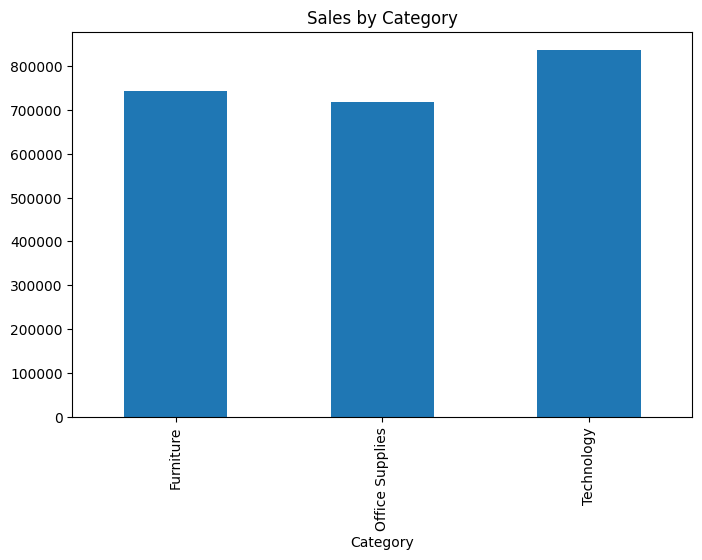

In [3]:
sales_category = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
sales_category.plot(kind="bar")
plt.title("Sales by Category")
plt.show()

## Top 10 Products

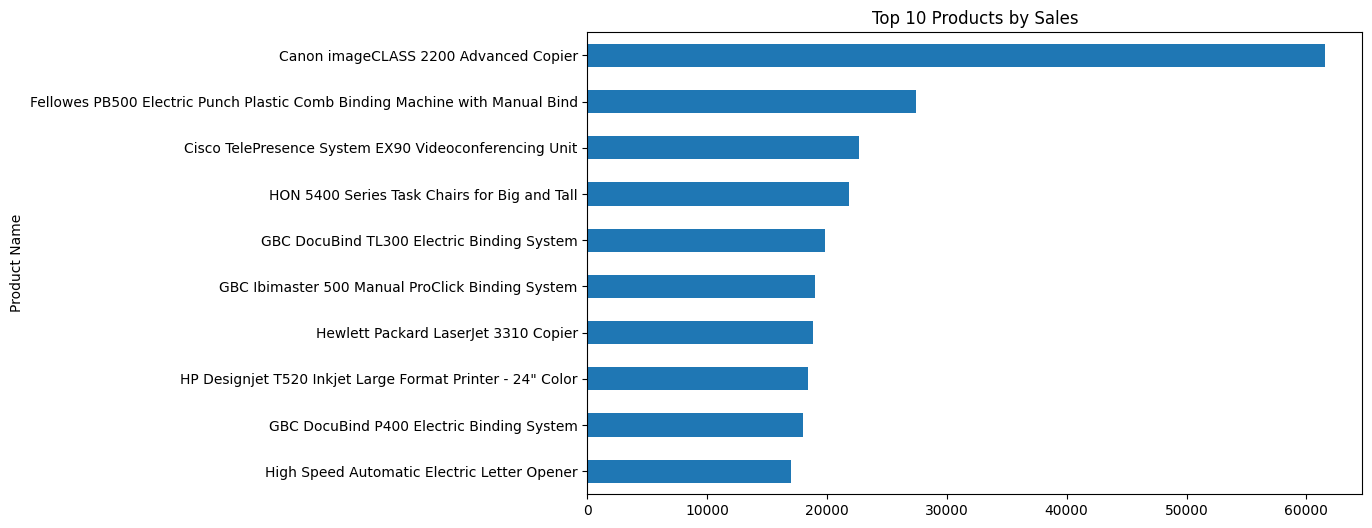

In [4]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,6))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.show()

## Monthly Sales Trend

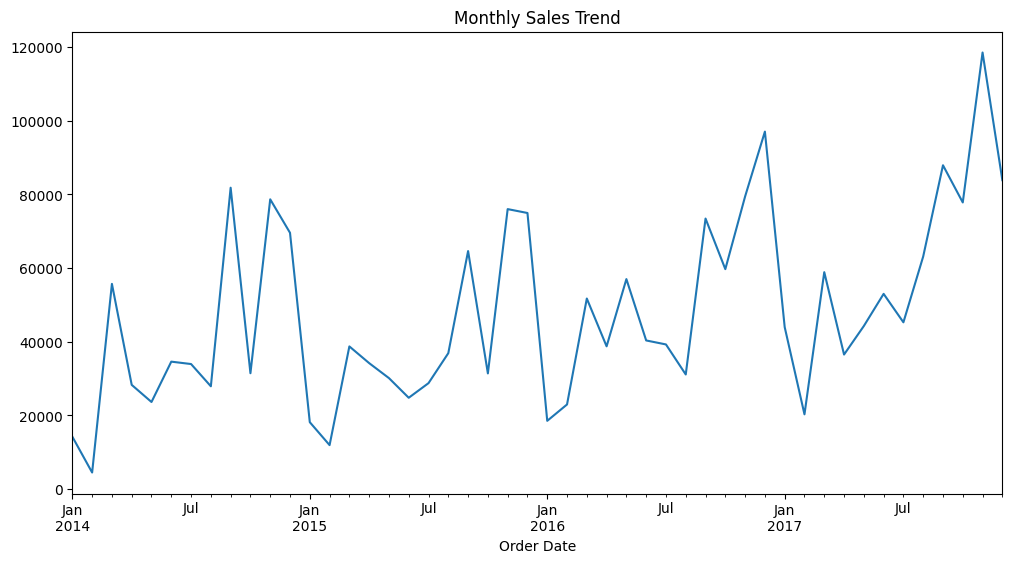

In [5]:
monthly_sales = (
    df.set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

## Key Insights

- Technology is the top-performing category  
- West region generates the highest revenue  
- Sales show strong monthly fluctuations with peak periods  